# A1 — Baysor / SSAM on real MERSCOPE WT vs AD

Post-hoc analysis of the raw detections from the HGCC sweep
(`../run_{baysor,ssam}_tile.py` → `../concat_spheres.py` → `../output/<method>/<config>/spheres.parquet`).

The pipeline has two parts, and the section numbers line up 1:1 with `A1_figures.R`'s across part B.

| | step | here | `A1_figures.R` |
|---|---|---|---|
| **A** | scale check → why `param = tuned` | §1 | — |
| | profile every tuned detection | §2 | — |
| | populations, annotation, and the three quality measures | §3 | — |
| | detection radius, and detection size | | §1 |
| | in-nucleus ratio, both denominators | | §2 |
| | negative-control ratio, both denominators | | §3 |
| **B** | compartment-marker mixing, and the granule-subtype heatmaps | §4 | §4 |
| | subdomain-anchored DE → GSEA + anchor comparison | §5 | §5 |
| | correctness gates (off by default) | §6 | — |
| | SSAM granule subtypes → subtype density | `A1_ssam_subtypes.ipynb` | §6 |

The numbering lines up 1:1 through §5. **§6 is the one place it does not**: this notebook's §6 is
the correctness gates and produces no figure, while `A1_figures.R` §6 draws the SSAM subtype
density from `A1_ssam_subtypes.ipynb`. Run order is this notebook → `A1_ssam_subtypes.ipynb` →
`A1_figures.R`.

**Where mcDETECT appears.** Part A describes the Baysor / SSAM detections on their own terms: no
mcDETECT data enters any part-A figure or table, and mcDETECT is cited there only as the source of a
threshold or a plotting style. Part B is the opposite by design — it exists to ask whether these
detections reproduce results mcDETECT reports, so mcDETECT is the reference throughout. The one
exception is §1 below, which compares detection *counts* against mcDETECT's granule count: that is
parameter selection — it is what justifies `param = tuned` — not a quality claim.

## The two settings and the populations

**Two parallel settings**, analyzed separately throughout (`param = tuned` in both):

| geneset | input to detection | populations |
|---|---|---|
| `all` | full 290-gene panel | `pop1`, `pop2`, `pop3` |
| `markers` | the 20 mcDETECT `syn_genes` | `pop1`, `pop2` |

| population | definition |
|---|---|
| `pop1` | all detections |
| `pop2` | out-of-nucleus — `in_soma_ratio_all < IN_SOMA_THR` (0.1, mcDETECT's own cutoff) |
| `pop3` | `pop2` **and** `marker_frac >= MARKER_FRAC_THR` — **`all` setting only** |

Both thresholds live in `postproc_config.py`; §3 prints a scan of `pop3` sizes across candidate
`marker_frac` cutoffs so `MARKER_FRAC_THR` can be retuned with one constant and a re-run. It is an
**absolute, uniform** cutoff on purpose — a per-sample one would give AD a looser bar (its panel-wide
marker background is 0.296 vs WT's 0.3235) and so would filter the two arms of the WT/AD contrast
asymmetrically.

`pop3` exists only for `all`: in the `markers` setting every transcript that formed the detection is
already a granule marker, so a marker-enrichment filter is vacuous.

**In-nucleus denominator.** `pop2` uses **all** transcripts in the sphere (`in_soma_ratio_all`).
mcDETECT itself uses marker-only (`model.py:102`, `258-267`), but under `all` many tuned Baysor
spheres hold zero marker transcripts, which would make that ratio undefined and collapse `pop2` into
`pop3`. The marker-only ratio is still computed and gets its own panels in `A1_figures.R` §2 — that
is where the sensitivity is read, rather than as a separate population.

**Expression quantification.** Every detection is quantified by the transcripts inside its
**enclosing sphere**, for both methods — mcDETECT's granule expression is sphere capture and SSAM
emits no molecule assignment, so this is the only rule that isolates the detection difference. For
Baysor the sphere captures a median ~1.4× more transcripts than Baysor assigns to that cell
(q95 ≈ 2.7×); disclose in Methods.

Run from this directory (`R2_revision/baysor_ssam_merscope/postproc/`) in `mcDETECT-env`, then run
`A1_figures.R`. Retired analyses and the reasoning behind retiring them are in `old/README.md`.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import scanpy as sc

sys.path.insert(0, str(Path.cwd()))          # run this notebook from postproc/
import postproc_config as C
import sphere_features as SF

warnings.filterwarnings("ignore")
sc.settings.verbosity = 1

C.POSTPROC_DIR.mkdir(parents=True, exist_ok=True)
C.ARMS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- runtime knobs ---------------- #
# OVERWRITE covers every cached artifact, not just the profiles: the section-4 subtype heatmaps
# and the section-5 DE tables are also skipped when their file already exists. On a re-run after
# ANY change to those sections, set this True (or delete the outputs) -- otherwise the old files
# survive and the notebook prints "cached" rather than failing.
OVERWRITE = False       # True -> recompute the cached per-detection profiles and derived tables
MAX_SPHERES = None      # e.g. 200_000 for a fast dry run (results are NOT cached); None = full data

CONFIGS = [(m, g) for m in C.METHODS for g in C.GENESETS]

print("detections :", C.OUT_ROOT)
print("postproc   :", C.POSTPROC_DIR)
print("param      :", C.PARAM, "| genesets:", C.GENESETS, "| methods:", C.METHODS)
print("thresholds : in_soma <", C.IN_SOMA_THR, "| marker_frac >=", C.MARKER_FRAC_THR)
print("spot grid   :", C.SPOT_GRID, "um | subdomain pair:", " vs ".join(C.SUBDOMAIN_PAIR))


/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-p

detections : /Users/chenyang/Desktop/mcDETECT/R2_revision/baysor_ssam_merscope/output
postproc   : /Users/chenyang/Desktop/mcDETECT/R2_revision/baysor_ssam_merscope/output/postproc
param      : tuned | genesets: ['all', 'markers'] | methods: ['baysor', 'ssam']
thresholds : in_soma < 0.1 | marker_frac >= 0.4
spot grid   : 50 um | subdomain pair: Subdomain 1 vs Subdomain 2


## 1. Scale check — both methods are off by orders of magnitude at their default settings

The only use of the `default` parameter arm: a bare count of detections next to mcDETECT's granule
count, for both gene sets. No filtering, no profiling.


In [2]:
summary = pd.read_csv(C.OUT_ROOT / "spheres_summary.csv")
assert (summary["n_tiles_missing"] == 0).all(), "sweep is incomplete -- rerun concat on HGCC"

# mcDETECT's final granules (row counts straight from the parquet footer)
mc_counts = {s: pq.ParquetFile(C.mcdetect_granules_path(s)).metadata.num_rows for s in C.SAMPLES}
print("mcDETECT granules:", mc_counts)

scale = summary.copy()
scale["mcdetect_granules"] = scale["sample"].map(mc_counts)
scale["ratio_vs_mcdetect"] = scale["n_spheres"] / scale["mcdetect_granules"]
scale = scale[["method", "geneset", "param", "sample", "n_spheres",
               "mcdetect_granules", "ratio_vs_mcdetect"]].sort_values(
                   ["method", "geneset", "param", "sample"])
scale.to_csv(C.POSTPROC_DIR / "detection_counts_vs_mcdetect.csv", index=False)
scale


mcDETECT granules: {'WT': 681337, 'AD': 398809}


,method,geneset,param,sample,n_spheres,mcdetect_granules,ratio_vs_mcdetect
4,baysor,all,default,AD,7324,398809,0.018365
0,baysor,all,default,WT,8968,681337,0.013162
6,baysor,all,tuned,AD,2464532,398809,6.179730
2,baysor,all,tuned,WT,3527958,681337,5.177993
5,baysor,markers,default,AD,5886,398809,0.014759
1,baysor,markers,default,WT,8187,681337,0.012016
7,baysor,markers,tuned,AD,687274,398809,1.723316
3,baysor,markers,tuned,WT,1083376,681337,1.590074
12,ssam,all,default,AD,97653,398809,0.244862
8,ssam,all,default,WT,97906,681337,0.143697


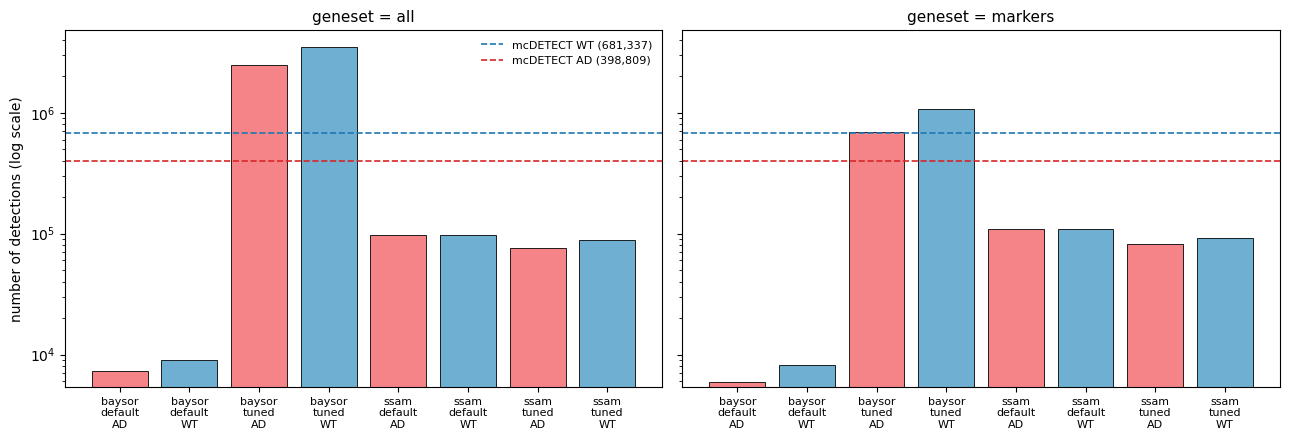

In [3]:
fig, axes = plt.subplots(1, len(C.GENESETS), figsize=(13, 4.5), sharey=True)
for ax, geneset in zip(np.atleast_1d(axes), C.GENESETS):
    sub = scale[scale["geneset"] == geneset]
    labels = [f"{r.method}\n{r.param}\n{r['sample']}" for _, r in sub.iterrows()]
    colors = ["#6fafd2" if r["sample"] == "WT" else "#f48488" for _, r in sub.iterrows()]
    ax.bar(range(len(sub)), sub["n_spheres"], color=colors, edgecolor="black", linewidth=0.6)
    for s, c in zip(C.SAMPLES, ["#1f77b4", "#d62728"]):
        ax.axhline(mc_counts[s], ls="--", lw=1.2, color=c, label=f"mcDETECT {s} ({mc_counts[s]:,})")
    ax.set_yscale("log")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f"geneset = {geneset}", fontsize=11)

np.atleast_1d(axes)[0].set_ylabel("number of detections (log scale)")
np.atleast_1d(axes)[0].legend(fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(C.POSTPROC_DIR / "detection_counts_vs_mcdetect.jpeg", dpi=300)
plt.show()


## 2. Profile every tuned detection (8 configs = 2 methods × 2 gene sets × 2 samples)

Count all transcripts inside each sphere and derive the granule-likeness features mcDETECT reports,
using the same query geometry as `mcDETECT.model.profile` (centre `[sphere_x, sphere_y, layer_z]`,
radius `sphere_r`). **Both** settings are profiled against the full 290-gene panel — mcDETECT
likewise seeds detection on 20 markers but profiles every gene (`3_detection.py:111`).

Results are cached per config, so the `all` configs are already on disk from the previous run and
only `markers` is built here.


In [4]:
feats_all, adatas = {}, {}

for sample in C.SAMPLES:
    # only read the (large) transcript table if something actually needs profiling
    needs_build = [
        (m, g) for (m, g) in CONFIGS
        if OVERWRITE or MAX_SPHERES is not None
        or not (C.features_path(m, sample, g).exists() and C.profile_path(m, sample, g).exists())
    ]
    transcripts = SF.load_transcripts(sample) if needs_build else None

    for method, geneset in CONFIGS:
        feats, adata = SF.build_features(method, sample, geneset, overwrite=OVERWRITE,
                                         max_spheres=MAX_SPHERES, transcripts=transcripts)
        feats_all[(method, geneset, sample)] = feats
        adatas[(method, geneset, sample)] = adata

    del transcripts

pd.DataFrame([{"method": m, "geneset": g, "sample": s, "n_detections": v.shape[0]}
              for (m, g, s), v in feats_all.items()])


[WT] 103,398,068 transcripts loaded in 3.7s
[build] baysor_WT_tuned_all
    3,527,958 raw detections
    panel genes: 290, markers: 33,303,096 transcripts, NC (19 genes): 2,937,582 transcripts
    KD-tree over 103,398,068 transcripts built in 39.9s
    profiled 250,000/3,527,958 spheres (1.8s)
    profiled 500,000/3,527,958 spheres (3.7s)
    profiled 750,000/3,527,958 spheres (5.6s)
    profiled 1,000,000/3,527,958 spheres (7.3s)
    profiled 1,250,000/3,527,958 spheres (9.0s)
    profiled 1,500,000/3,527,958 spheres (10.8s)
    profiled 1,750,000/3,527,958 spheres (12.5s)
    profiled 2,000,000/3,527,958 spheres (14.1s)
    profiled 2,250,000/3,527,958 spheres (15.7s)
    profiled 2,500,000/3,527,958 spheres (17.3s)
    profiled 2,750,000/3,527,958 spheres (18.8s)
    profiled 3,000,000/3,527,958 spheres (20.4s)
    profiled 3,250,000/3,527,958 spheres (22.0s)
    profiled 3,500,000/3,527,958 spheres (23.5s)
    profiled 3,527,958/3,527,958 spheres (23.7s)
    done: 3,527,958 spheres

,method,geneset,sample,n_detections
0,baysor,all,WT,3527958
1,baysor,markers,WT,1083376
2,ssam,all,WT,88517
3,ssam,markers,WT,92687
4,baysor,all,AD,2464532
5,baysor,markers,AD,687274
6,ssam,all,AD,76373
7,ssam,markers,AD,82563


## 3. Populations, spatial annotation, and persistence

`pop2` applies mcDETECT's 0.1 in-nucleus cutoff; `pop3` (`all` only) additionally requires at least
`MARKER_FRAC_THR` of the sphere's transcripts to be granule markers.

**This cell writes everything back into `<config>_features.parquet`**, which is the single source of
truth for detection-level annotation, and carries the same flags onto the profile `AnnData` so
sections 4–5 can subset it without re-reading.

This section also writes the three part-A exports that `A1_figures.R` sections 1–3 consume: the
radius table, and the binned in-nucleus and NC histograms with their quantile summaries.


In [5]:
marker_share = {s: SF.sample_marker_share(s) for s in C.SAMPLES}
print("panel-wide marker share (background for the marker_frac threshold):",
      {k: round(v, 4) for k, v in marker_share.items()})

summaries = []
for (method, geneset, sample), feats in list(feats_all.items()):
    print(f"[{method} / {geneset} / {sample}]")
    feats = SF.assign_populations(feats, geneset)

    feats.to_parquet(C.features_path(method, sample, geneset), index=False)
    feats_all[(method, geneset, sample)] = feats

    # carry the flags onto the AnnData so sections 4-5 can subset it directly
    carry = C.populations(geneset) + ["marker_frac"]
    for col in carry:
        adatas[(method, geneset, sample)].obs[col] = feats[col].to_numpy()

    summaries.append(SF.population_summary(feats, method, sample, geneset))

pop_summary = pd.concat(summaries, ignore_index=True)
pop_summary.to_csv(C.POSTPROC_DIR / "population_summary.csv", index=False)

# sanity: populations nest, and `markers` has no pop3
for (method, geneset, sample), f in feats_all.items():
    assert (f["pop2"] <= f["pop1"]).all(), (method, geneset, sample)
    if geneset == "all":
        assert (f["pop3"] <= f["pop2"]).all(), (method, geneset, sample)
    else:
        assert "pop3" not in f.columns, (method, geneset, sample)

pop_summary


panel-wide marker share (background for the marker_frac threshold): {'WT': 0.3235, 'AD': 0.296}
[baysor / all / WT]
    pop1=3,527,958  pop2=1,903,897  pop3=804,184 (marker_frac >= 0.4)
[baysor / markers / WT]
    pop1=1,083,376  pop2=632,039
[ssam / all / WT]
    pop1=88,517  pop2=49,785  pop3=21,713 (marker_frac >= 0.4)
[ssam / markers / WT]
    pop1=92,687  pop2=61,163
[baysor / all / AD]
    pop1=2,464,532  pop2=1,318,354  pop3=416,989 (marker_frac >= 0.4)
[baysor / markers / AD]
    pop1=687,274  pop2=375,313
[ssam / all / AD]
    pop1=76,373  pop2=44,409  pop3=18,594 (marker_frac >= 0.4)
[ssam / markers / AD]
    pop1=82,563  pop2=54,768


,method,sample,geneset,population,n_detections,frac_of_all,median_sphere_r,median_n_total,median_n_marker,median_comp,median_in_soma_ratio_all,median_nc_ratio_all
0,baysor,WT,all,pop1,3527958,1.000000,2.320286,37.0,12.0,24.0,0.019417,0.012987
1,baysor,WT,all,pop2,1903897,0.539660,2.490495,32.0,12.0,21.0,0.000000,0.000000
2,baysor,WT,all,pop3,804184,0.227946,2.540863,34.0,17.0,20.0,0.000000,0.000000
3,baysor,WT,markers,pop1,1083376,1.000000,3.087683,77.0,28.0,40.0,0.000000,0.016022
4,baysor,WT,markers,pop2,632039,0.583398,3.183296,63.0,26.0,32.0,0.000000,0.000000
5,ssam,WT,all,pop1,88517,1.000000,1.500000,10.0,3.0,9.0,0.000000,0.000000
6,ssam,WT,all,pop2,49785,0.562434,1.500000,7.0,3.0,6.0,0.000000,0.000000
7,ssam,WT,all,pop3,21713,0.245298,1.500000,7.0,4.0,6.0,0.000000,0.000000
8,ssam,WT,markers,pop1,92687,1.000000,1.500000,9.0,4.0,8.0,0.000000,0.000000
9,ssam,WT,markers,pop2,61163,0.659888,1.500000,7.0,3.0,6.0,0.000000,0.000000


In [6]:
# Radius table for A1_figures.R section 1.
#
# BOTH methods are exported, but only Baysor is plotted. SSAM's sphere_r is the constant we set
# (SSAM_DETECTION_RADIUS = 1.5 um in ../config.py), so it has no distribution to compare -- it
# belongs in the summary table so a reader can see it was excluded deliberately, not overlooked.
rad = []
for method in C.METHODS:
    for geneset in C.GENESETS:
        for sample in C.SAMPLES:
            f = feats_all[(method, geneset, sample)]
            d = {"method": method, "geneset": geneset, "sample": sample,
                 "sphere_r": f["sphere_r"].to_numpy(),
                 # Baysor's own molecule-per-segment count. SSAM assigns no molecules to an
                 # object, so the column is absent there and stays NaN -- which is the point:
                 # its radius is the constant we supplied, not something the data determined.
                 "n_molecules": (f["n_molecules"].to_numpy(dtype=float)
                                 if "n_molecules" in f.columns
                                 else np.full(len(f), np.nan)),
                 "pop1": f["pop1"].to_numpy(), "pop2": f["pop2"].to_numpy()}
            d["pop3"] = f["pop3"].to_numpy() if "pop3" in f.columns else np.zeros(len(f), dtype=bool)
            rad.append(pd.DataFrame(d))

rad = pd.concat(rad, ignore_index=True)
rad.to_parquet(C.POSTPROC_DIR / "radius_populations.parquet", index=False)
print(f"wrote radius_populations.parquet ({rad.shape[0]:,} rows)")

# Assert SSAM's radius really is one constant, so a change in the detection stage cannot quietly
# turn "constant, therefore uninformative" into a false statement in the figure legend.
ssam_r = np.unique(rad.loc[rad["method"] == "ssam", "sphere_r"].to_numpy())
print("SSAM distinct radii:", ssam_r)
assert ssam_r.size == 1, "SSAM radius is no longer constant -- revisit why section 1 excludes it"

rad.groupby(["method", "geneset", "sample"]).size()


# ---------------------------------------------------------------------------------------------- #
# mcDETECT baseline for the radius / detection-size tables.
#
# A STANDALONE table, deliberately not merged into R's radius_summary.csv / size_summary.csv:
# part A describes the Baysor / SSAM detections on their own terms and no mcDETECT row may enter
# those panels. It exists so the response letter can quote mcDETECT's own radius / size next to
# them without reopening the h5ad (R cannot read one). Same granule object section 4 uses as its
# entropy reference. Reported per sample and pooled, because the manuscript quotes the WT figure.
# ---------------------------------------------------------------------------------------------- #
_mcd = anndata.read_h5ad(C.MCDETECT_GRANULE_ADATA)
_b = _mcd.obs["batch"].astype(str)
_rows = []
for _lab, _m in ([(s_, _b.str.contains(s_).to_numpy()) for s_ in C.SAMPLES]
                 + [("pooled", np.ones(_mcd.n_obs, dtype=bool))]):
    _r = _mcd.obs.loc[_m, "sphere_r"].to_numpy(dtype=float)
    _rows.append({
        "method": "mcdetect", "sample": _lab, "n_granules": int(_m.sum()),
        "median_radius": float(np.median(_r)),
        "q05_radius": float(np.quantile(_r, 0.05)), "q95_radius": float(np.quantile(_r, 0.95)),
        "median_transcripts": float(_mcd.obs.loc[_m, "size"].median()),
        "median_genes": float(_mcd.obs.loc[_m, "comp"].median()),
    })
mcdetect_baseline = pd.DataFrame(_rows)
mcdetect_baseline.to_csv(C.POSTPROC_DIR / "mcdetect_baseline.csv", index=False)
del _mcd, _b, _rows
print("wrote mcdetect_baseline.csv")
mcdetect_baseline.round(3)


wrote radius_populations.parquet (8,103,280 rows)
SSAM distinct radii: [1.5]
wrote mcdetect_baseline.csv


,method,sample,n_granules,median_radius,q05_radius,q95_radius,median_transcripts,median_genes
0,mcdetect,WT,681337,0.933,0.508,1.766,4.0,2.0
1,mcdetect,AD,398809,0.952,0.507,1.929,4.0,2.0
2,mcdetect,pooled,1080146,0.940,0.508,1.827,4.0,2.0


### Tuning aid — `pop3` size across candidate `marker_frac` cutoffs

`MARKER_FRAC_THR` is a judgement call, so here is what each candidate costs. Read it against the
panel-wide marker share (the fraction expected **by chance**): a cutoff at or below that share does
not select enriched detections at all, it selects typical ones.

Changes nothing downstream — set the constant in `postproc_config.py` and re-run section 3.


In [7]:
SCAN = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
pooled_share = (sum(marker_share[s] * feats_all[("baysor", "all", s)].shape[0] for s in C.SAMPLES)
                / sum(feats_all[("baysor", "all", s)].shape[0] for s in C.SAMPLES))

scan_rows = []
for (method, geneset, sample), feats in feats_all.items():
    if geneset != "all":            # pop3 is only defined for the all-genes setting
        continue
    mf = feats.loc[feats["pop2"], "marker_frac"].to_numpy()
    mf = mf[~np.isnan(mf)]
    for thr in SCAN:
        scan_rows.append({"method": method, "sample": sample, "n_pop2": int(mf.size),
                          "threshold": thr,
                          "x_background": round(thr / marker_share[sample], 2),
                          "n_pop3": int((mf >= thr).sum()),
                          "frac_of_pop2": float((mf >= thr).mean())})

scan = pd.DataFrame(scan_rows)
scan.to_csv(C.POSTPROC_DIR / "marker_frac_threshold_scan.csv", index=False)

print("panel-wide marker share (expected by chance):",
      {k: round(v, 4) for k, v in marker_share.items()}, f"| pooled ~{pooled_share:.4f}")
print(f"current MARKER_FRAC_THR = {C.MARKER_FRAC_THR} "
      f"({C.MARKER_FRAC_THR / pooled_share:.2f}x the pooled background)")
below = sorted({t for t in SCAN if t <= max(marker_share.values())})
if below:
    print(f"!! at or below background, i.e. not enrichment: {below}")

scan.pivot_table(index=["method", "sample"], columns="threshold", values="n_pop3")


panel-wide marker share (expected by chance): {'WT': 0.3235, 'AD': 0.296} | pooled ~0.3122
current MARKER_FRAC_THR = 0.4 (1.28x the pooled background)
!! at or below background, i.e. not enrichment: [0.3]


threshold           0.30       0.35      0.40      0.45      0.50      0.55  \
method sample                                                                 
baysor AD       738146.0   570034.0  416989.0  272804.0  182756.0   95781.0   
       WT      1322922.0  1067814.0  804184.0  532978.0  347159.0  169727.0   
ssam   AD        26162.0    21348.0   18594.0   14053.0   12773.0    8095.0   
       WT        29860.0    24425.0   21713.0   16560.0   15393.0    9516.0   

threshold         0.60  
method sample           
baysor AD      51037.0  
       WT      82828.0  
ssam   AD       6411.0  
       WT       7758.0

### In-nucleus ratio per population — summary + binned histogram

For `A1_figures.R` section 2. Both methods, both gene sets, every population, and **both
denominators**:

* `in_soma_ratio_all` — every transcript inside the detection (the primary filter, and what
  defines `pop2`);
* `in_soma_ratio_marker` — granule-marker transcripts only, mcDETECT's own definition, reported
  alongside as a sensitivity column.

The distributions pile up hard at zero, so rather than shipping ~8 M raw values to R this exports a
pre-binned histogram (0.02-wide bins) plus the quantiles — R can plot either, or just print the
numbers.

Read `pop2`/`pop3` with care: they are *defined by* `in_soma_ratio_all < 0.1`, so their
distributions are truncated by construction. `pop1` is the informative one — it says how somatic
each method's raw detections are.


In [8]:
BINS = np.linspace(0, 1, 51)          # 0.02-wide bins

summary_rows, hist_rows = [], []


def _record(values, **keys):
    x = np.asarray(values, dtype=float)
    n_nan = int(np.isnan(x).sum())
    x = x[~np.isnan(x)]
    if x.size == 0:
        return
    q = np.quantile(x, [0.05, 0.25, 0.5, 0.75, 0.95])
    summary_rows.append({**keys, "n": int(x.size), "n_undefined": n_nan,
                         "mean": float(x.mean()), "q05": q[0], "q25": q[1], "median": q[2],
                         "q75": q[3], "q95": q[4],
                         "frac_zero": float((x == 0).mean()),
                         "frac_below_0.1": float((x < C.IN_SOMA_THR).mean())})
    counts, _ = np.histogram(x, bins=BINS)
    for lo, hi, c in zip(BINS[:-1], BINS[1:], counts):
        hist_rows.append({**keys, "bin_lo": float(lo), "bin_hi": float(hi),
                          "count": int(c), "frac": float(c) / x.size})


for (method, geneset, sample), feats in feats_all.items():
    for population in C.populations(geneset):
        sel = feats[feats[population]]
        for ratio, col in [("all", "in_soma_ratio_all"), ("marker", "in_soma_ratio_marker")]:
            _record(sel[col], method=method, geneset=geneset, sample=sample,
                    population=population, ratio=ratio)

in_soma_summary = pd.DataFrame(summary_rows)
in_soma_summary.to_csv(C.POSTPROC_DIR / "in_soma_summary.csv", index=False)
pd.DataFrame(hist_rows).to_parquet(C.POSTPROC_DIR / "in_soma_histogram.parquet", index=False)
print(f"wrote in_soma_summary.csv ({in_soma_summary.shape[0]} rows) and in_soma_histogram.parquet")

in_soma_summary[in_soma_summary["ratio"] == "all"].round(4)


wrote in_soma_summary.csv (40 rows) and in_soma_histogram.parquet


,method,geneset,sample,population,ratio,n,n_undefined,mean,q05,q25,median,q75,q95,frac_zero,frac_below_0.1
0,baysor,all,WT,pop1,all,3527958,0,0.2882,0.0,0.0,0.0194,0.6154,0.9565,0.4961,0.5397
2,baysor,all,WT,pop2,all,1903897,0,0.0042,0.0,0.0,0.0000,0.0000,0.0417,0.9192,1.0000
4,baysor,all,WT,pop3,all,804184,0,0.0027,0.0,0.0,0.0000,0.0000,0.0161,0.9468,1.0000
6,baysor,markers,WT,pop1,all,1083376,0,0.2302,0.0,0.0,0.0000,0.4706,0.8621,0.5178,0.5834
8,baysor,markers,WT,pop2,all,632039,0,0.0052,0.0,0.0,0.0000,0.0000,0.0482,0.8875,1.0000
10,ssam,all,WT,pop1,all,88117,400,0.3349,0.0,0.0,0.0000,0.8000,1.0000,0.5559,0.5650
12,ssam,all,WT,pop2,all,49785,0,0.0010,0.0,0.0,0.0000,0.0000,0.0000,0.9839,1.0000
14,ssam,all,WT,pop3,all,21713,0,0.0005,0.0,0.0,0.0000,0.0000,0.0000,0.9918,1.0000
16,ssam,markers,WT,pop1,all,92234,453,0.2501,0.0,0.0,0.0000,0.5500,1.0000,0.6532,0.6631
18,ssam,markers,WT,pop2,all,61163,0,0.0009,0.0,0.0,0.0000,0.0000,0.0000,0.9851,1.0000


### Negative-control ratio per population — summary + binned histogram

For `A1_figures.R` section 3, deliberately the same shape as the in-nucleus export above so the two
read identically. Both methods, both gene sets, every population, and **both denominators**:

* `nc_ratio_all` — `n_nc / n_total`, every transcript inside the detection;
* `nc_ratio_marker` — `n_nc / n_marker`, granule-marker transcripts only (mcDETECT's own
  denominator).

`n_nc` counts the top-`NC_TOP` negative-control genes by abundance, selected exactly as
`model.py::nc_filter` selects them.

**Nothing in this pipeline filters on NC ratio** — not the detection sweep, not `pop2`, not `pop3`,
and no population definition touches `nc_top` or `nc_thr`. So unlike the in-nucleus ratio these
distributions are not truncated by construction, and the `pop1 → pop2 → pop3` trend is a real read
in whichever direction it runs.

One caveat: `nc_ratio_marker` shares `n_marker` with the `marker_frac >= 0.4` cut that defines
`pop3`, so it shifts there partly mechanically. Read the all-transcript column for `pop3`; the
marker one is a sensitivity check.


In [9]:
# 0.02-wide bins plus an overflow bin: nc_ratio_marker = n_nc / n_marker is not bounded by 1
NC_BINS = np.append(np.linspace(0, 1, 51), np.inf)

nc_summary_rows, nc_hist_rows = [], []


def _record_nc(values, **keys):
    """Same shape as `_record` above -- quantiles plus a binned histogram."""
    x = np.asarray(values, dtype=float)
    n_nan = int(np.isnan(x).sum())
    x = x[~np.isnan(x)]
    if x.size == 0:
        return
    q = np.quantile(x, [0.05, 0.25, 0.5, 0.75, 0.95])
    nc_summary_rows.append({**keys, "n": int(x.size), "n_undefined": n_nan,
                            "mean": float(x.mean()), "q05": q[0], "q25": q[1], "median": q[2],
                            "q75": q[3], "q95": q[4],
                            "frac_zero": float((x == 0).mean())})
    counts, _ = np.histogram(x, bins=NC_BINS)
    for lo, hi, c in zip(NC_BINS[:-1], NC_BINS[1:], counts):
        nc_hist_rows.append({**keys, "bin_lo": float(lo), "bin_hi": float(hi),
                             "count": int(c), "frac": float(c) / x.size})


for (method, geneset, sample), feats in feats_all.items():
    for population in C.populations(geneset):
        sel = feats[feats[population]]
        for ratio, col in [("all", "nc_ratio_all"), ("marker", "nc_ratio_marker")]:
            _record_nc(sel[col], method=method, geneset=geneset, sample=sample,
                       population=population, ratio=ratio)

nc_summary = pd.DataFrame(nc_summary_rows)
nc_summary.to_csv(C.POSTPROC_DIR / "nc_summary.csv", index=False)
pd.DataFrame(nc_hist_rows).to_parquet(C.POSTPROC_DIR / "nc_histogram.parquet", index=False)
print(f"wrote nc_summary.csv ({nc_summary.shape[0]} rows) and nc_histogram.parquet")

nc_summary[nc_summary["ratio"] == "all"].round(4)


wrote nc_summary.csv (40 rows) and nc_histogram.parquet


,method,geneset,sample,population,ratio,n,n_undefined,mean,q05,q25,median,q75,q95,frac_zero
0,baysor,all,WT,pop1,all,3527958,0,0.0293,0.0,0.0,0.0130,0.0455,0.1136,0.4836
2,baysor,all,WT,pop2,all,1903897,0,0.0123,0.0,0.0,0.0000,0.0204,0.0588,0.6829
4,baysor,all,WT,pop3,all,804184,0,0.0103,0.0,0.0,0.0000,0.0161,0.0526,0.7134
6,baysor,markers,WT,pop1,all,1083376,0,0.0260,0.0,0.0,0.0160,0.0385,0.0921,0.3603
8,baysor,markers,WT,pop2,all,632039,0,0.0108,0.0,0.0,0.0000,0.0182,0.0417,0.5465
10,ssam,all,WT,pop1,all,88117,400,0.0340,0.0,0.0,0.0000,0.0476,0.1724,0.7050
12,ssam,all,WT,pop2,all,49785,0,0.0120,0.0,0.0,0.0000,0.0000,0.0909,0.8812
14,ssam,all,WT,pop3,all,21713,0,0.0094,0.0,0.0,0.0000,0.0000,0.0769,0.9070
16,ssam,markers,WT,pop1,all,92234,453,0.0288,0.0,0.0,0.0000,0.0345,0.1579,0.7362
18,ssam,markers,WT,pop2,all,61163,0,0.0105,0.0,0.0,0.0000,0.0000,0.0833,0.8927


## 4. Compartment-marker mixing -- how mixed is a single detection?

mcDETECT's granule subtypes come from clustering detections on 34 compartment markers
(`C.REF_GENES`), so how *concentrated* a detection's profile is over those markers is the
per-detection precursor of whether it earns a pure subtype label. Measuring it directly avoids the
manual cluster -> compartment mapping, which has to be redone per method and is a judgement call.

Per detection, with `p` the profile over the markers normalised to sum 1:

| column | meaning |
|---|---|
| `n_ref` | marker transcripts in the detection |
| `entropy` | `-sum(p log p)`, nats |
| `entropy_norm` | `entropy / log(n markers)` -- **0 = one marker only, 1 = uniform** |
| `perplexity` | `exp(entropy)` -- effective number of distinct markers |
| `top1_share` | largest single-marker share |

**No gene -> compartment grouping is applied**: mcDETECT assigns compartments at the cluster level,
never gene by gene, so a gene-wise map would be this script's invention. All four numbers are
properties of the count vector.

Detections with `n_ref == 0` have no profile. They are reported as `n_undefined` / `frac_undefined`
rather than dropped, because that fraction is itself method-dependent.

mcDETECT's own granules are exported as the reference distribution, on the same 34 markers.


In [10]:
ENT_BINS = np.linspace(0, 1, 51)         # entropy_norm is bounded [0, 1] -> 0.02-wide bins

ent_summary_rows, ent_hist_rows = [], []


def _record_entropy(df, **keys):
    """Quantiles + a binned entropy_norm histogram, mirroring the section-3 exports."""
    n_total = int(df.shape[0])
    x = df["entropy_norm"].to_numpy(dtype=float)
    n_undef = int(np.isnan(x).sum())
    x = x[~np.isnan(x)]
    if n_total == 0:
        return
    defined = df[df["n_ref"] > 0]
    q = np.quantile(x, [0.05, 0.25, 0.5, 0.75, 0.95]) if x.size else [np.nan] * 5
    ent_summary_rows.append({
        **keys, "n": n_total, "n_defined": int(x.size), "n_undefined": n_undef,
        "frac_undefined": float(n_undef) / n_total,
        "mean": float(x.mean()) if x.size else np.nan,
        "q05": q[0], "q25": q[1], "median": q[2], "q75": q[3], "q95": q[4],
        "median_perplexity": float(defined["perplexity"].median()) if defined.shape[0] else np.nan,
        "median_top1_share": float(defined["top1_share"].median()) if defined.shape[0] else np.nan,
        "frac_pure": float((defined["top1_share"] >= 0.9).mean()) if defined.shape[0] else np.nan,
        "median_n_ref": float(df["n_ref"].median()),
    })
    if x.size:
        counts, _ = np.histogram(x, bins=ENT_BINS)
        for lo, hi, c in zip(ENT_BINS[:-1], ENT_BINS[1:], counts):
            ent_hist_rows.append({**keys, "bin_lo": float(lo), "bin_hi": float(hi),
                                  "count": int(c), "frac": float(c) / x.size})


for (method, geneset, sample), adata in adatas.items():
    ent = SF.marker_entropy(adata, verbose=False)
    for population in C.populations(geneset):
        mask = adata.obs[population].to_numpy().astype(bool)
        print(f"[{method}/{geneset}/{population}/{sample}] {int(mask.sum()):,} detections")
        _record_entropy(ent[mask], method=method, geneset=geneset,
                        sample=sample, population=population)

# mcDETECT granules -- the reference distribution, same 34 markers, same statistic
mcd = anndata.read_h5ad(C.MCDETECT_GRANULE_ADATA)
mcd_batch = mcd.obs["batch"].astype(str)
mcd_ent = SF.marker_entropy(mcd, verbose=False)
for sample in C.SAMPLES:
    mask = mcd_batch.str.contains(sample).to_numpy()
    print(f"[mcdetect/granules/{sample}] {int(mask.sum()):,} granules")
    _record_entropy(mcd_ent[mask], method="mcdetect", geneset="granules",
                    sample=sample, population="pop1")
del mcd, mcd_ent

entropy_summary = pd.DataFrame(ent_summary_rows)
entropy_summary.to_csv(C.POSTPROC_DIR / "entropy_summary.csv", index=False)
pd.DataFrame(ent_hist_rows).to_parquet(C.POSTPROC_DIR / "entropy_histogram.parquet", index=False)
print(f"\nwrote entropy_summary.csv ({entropy_summary.shape[0]} rows) and entropy_histogram.parquet")

entropy_summary[["method", "geneset", "population", "sample", "n", "frac_undefined",
                 "median", "median_perplexity", "frac_pure"]].round(4)


[baysor/all/pop1/WT] 3,527,958 detections
[baysor/all/pop2/WT] 1,903,897 detections
[baysor/all/pop3/WT] 804,184 detections
[baysor/markers/pop1/WT] 1,083,376 detections
[baysor/markers/pop2/WT] 632,039 detections
[ssam/all/pop1/WT] 88,517 detections
[ssam/all/pop2/WT] 49,785 detections
[ssam/all/pop3/WT] 21,713 detections
[ssam/markers/pop1/WT] 92,687 detections
[ssam/markers/pop2/WT] 61,163 detections
[baysor/all/pop1/AD] 2,464,532 detections
[baysor/all/pop2/AD] 1,318,354 detections
[baysor/all/pop3/AD] 416,989 detections
[baysor/markers/pop1/AD] 687,274 detections
[baysor/markers/pop2/AD] 375,313 detections
[ssam/all/pop1/AD] 76,373 detections
[ssam/all/pop2/AD] 44,409 detections
[ssam/all/pop3/AD] 18,594 detections
[ssam/markers/pop1/AD] 82,563 detections
[ssam/markers/pop2/AD] 54,768 detections
[mcdetect/granules/WT] 681,337 granules
[mcdetect/granules/AD] 398,809 granules

wrote entropy_summary.csv (22 rows) and entropy_histogram.parquet


,method,geneset,population,sample,n,frac_undefined,median,median_perplexity,frac_pure
0,baysor,all,pop1,WT,3527958,0.0070,0.5235,6.3358,0.0195
1,baysor,all,pop2,WT,1903897,0.0053,0.4957,5.7423,0.0161
2,baysor,all,pop3,WT,804184,0.0000,0.5177,6.2063,0.0003
3,baysor,markers,pop1,WT,1083376,0.0000,0.6258,9.0862,0.0000
4,baysor,markers,pop2,WT,632039,0.0000,0.5801,7.7336,0.0000
5,ssam,all,pop1,WT,88517,0.1178,0.3115,3.0000,0.1900
6,ssam,all,pop2,WT,49785,0.1155,0.2948,2.8284,0.2108
7,ssam,all,pop3,WT,21713,0.0000,0.3115,3.0000,0.0947
8,ssam,markers,pop1,WT,92687,0.0349,0.3115,3.0000,0.1237
9,ssam,markers,pop2,WT,61163,0.0349,0.3115,3.0000,0.1492


### Granule-subtype heatmaps per population

The visual counterpart of the entropy numbers above, and the panel that shows *why* they matter.
mcDETECT's granule subtypes come from clustering detections on the 34 `REF_GENES`; each cluster is
dominated by one or a few markers, which is what makes a cluster interpretable as a compartment.
Running the identical procedure on the Baysor / SSAM detections asks whether their detections
resolve into compartment-specific groups at all.

The procedure is mcDETECT's own, unchanged (`code/benchmark/benchmark_subtyping.ipynb`,
`run_manual_subtyping()` in cell 15 and the heatmap in cell 22): normalise on the **full 290-gene
panel**, then subset to `REF_GENES`; `MiniBatchKMeans(15, batch_size=5000, n_init=20,
random_state=C.SUBTYPE_SEED)` on the marker matrix, no PCA and no plain KMeans; then
`sc.pl.heatmap(cmap="Reds", standard_scale="var", swap_axes=True, dendrogram=False,
figsize=(10, 6))` at dpi 500. Panels are therefore directly comparable to
`output/MERSCOPE_WT_AD_comparison/heatmap_subtype.jpeg`.

**Only the figure is produced here.** No subtype labels are exported from this section and nothing
downstream reads them: the panels are the result, and the comparison they support is Baysor's
against SSAM's.

What the panels show is that the two methods differ. **Baysor's clusters have no block structure** —
the same markers are elevated across nearly every cluster, so no cluster corresponds to a
compartment and no manual cluster → compartment mapping can honestly be made for it. **SSAM's do
resolve**, with distinct `Camk2a`, `Vamp2`, `Ddn`, `Shank1`, `Slc17a7` and `Syp`/`Syt1` blocks. That
asymmetry is why `A1_ssam_subtypes.ipynb` exists, why it re-clusters from scratch with its own
per-population seed, and why it covers **SSAM only**.

`sc.pl.heatmap` draws one column per detection and `baysor`/`all`/`pop1` holds ~6 M, so each arm is
reduced to a seeded random subsample of at most `HEATMAP_MAX_CELLS` (200,000) used for both the
clustering fit and the plot. Arms below that use every detection; the printed size is what the
figure caption should quote.


In [11]:
heatmap_dir = C.POSTPROC_DIR / "subtype_heatmaps"
heatmap_dir.mkdir(parents=True, exist_ok=True)

# Subsample BEFORE copying, not inside subtype_heatmap. baysor/all/pop1 is ~6 M detections x 290
# genes; copying it whole (twice, once per sample, plus the concat) would peak around 9 GB on top of
# the eight profiles already resident from section 2, only for 97% of it to be discarded. Drawing
# the sample first keeps the whole section at a few hundred MB. Both samples are pooled, exactly as
# mcDETECT clusters WT and AD granules together, and each contributes in proportion to its size.
_rng = np.random.default_rng(C.HEATMAP_SEED)

heatmap_index = []
for method, geneset in CONFIGS:
    for population in C.populations(geneset):
        out_path = heatmap_dir / f"{method}_{geneset}_{population}.jpeg"
        tag = f"{method}/{geneset}/{population}"

        masks = {s: adatas[(method, geneset, s)].obs[population].to_numpy().astype(bool)
                 for s in C.SAMPLES}
        n_total = int(sum(m.sum() for m in masks.values()))
        if n_total == 0:
            print(f"[{tag}] no detections -- skipped")
            continue

        # proportional allocation, so the WT:AD ratio of the arm is preserved in the panel
        take = {s: int(round(C.HEATMAP_MAX_CELLS * m.sum() / n_total)) if n_total > C.HEATMAP_MAX_CELLS
                   else int(m.sum())
                for s, m in masks.items()}

        heatmap_index.append({"method": method, "geneset": geneset, "population": population,
                              "n_detections": n_total, "n_plotted": int(sum(take.values()))})

        if out_path.exists() and not OVERWRITE:
            print(f"[{tag}] cached  ({n_total:,} detections)")
            continue

        parts = []
        for sample in C.SAMPLES:
            idx = np.flatnonzero(masks[sample])
            if idx.size == 0 or take[sample] == 0:
                continue
            if take[sample] < idx.size:
                idx = np.sort(_rng.choice(idx, take[sample], replace=False))
            parts.append(adatas[(method, geneset, sample)][idx].copy())
        if not parts:
            continue

        arm = anndata.concat(parts, index_unique="-")
        del parts
        print(f"[{tag}] {n_total:,} detections -> {arm.n_obs:,} plotted")
        SF.subtype_heatmap(arm, out_path,
                           title=f"{method} | {geneset} | {population}"
                                 f"  (n = {n_total:,}; {arm.n_obs:,} shown)")
        del arm

heatmap_index = pd.DataFrame(heatmap_index)
heatmap_index.to_csv(C.POSTPROC_DIR / "subtype_heatmap_index.csv", index=False)
print(f"\nwrote subtype_heatmap_index.csv ({heatmap_index.shape[0]} arms) -- "
      f"the n shown there is what the figure captions should quote")
heatmap_index


[baysor/all/pop1] 5,992,490 detections -> 200,000 plotted
    clustered 200,000 detections on 34/34 markers, k = 15, seed = 1
    wrote baysor_all_pop1.jpeg
[baysor/all/pop2] 3,222,251 detections -> 200,000 plotted
    clustered 200,000 detections on 34/34 markers, k = 15, seed = 1
    wrote baysor_all_pop2.jpeg
[baysor/all/pop3] 1,221,173 detections -> 200,000 plotted
    clustered 200,000 detections on 34/34 markers, k = 15, seed = 1
    wrote baysor_all_pop3.jpeg
[baysor/markers/pop1] 1,770,650 detections -> 200,000 plotted
    clustered 200,000 detections on 34/34 markers, k = 15, seed = 1
    wrote baysor_markers_pop1.jpeg
[baysor/markers/pop2] 1,007,352 detections -> 200,000 plotted
    clustered 200,000 detections on 34/34 markers, k = 15, seed = 1
    wrote baysor_markers_pop2.jpeg
[ssam/all/pop1] 164,890 detections -> 164,890 plotted
    clustered 164,890 detections on 34/34 markers, k = 15, seed = 1
    wrote ssam_all_pop1.jpeg
[ssam/all/pop2] 94,194 detections -> 94,194 plot

,method,geneset,population,n_detections,n_plotted
0,baysor,all,pop1,5992490,200000
1,baysor,all,pop2,3222251,200000
2,baysor,all,pop3,1221173,200000
3,baysor,markers,pop1,1770650,200000
4,baysor,markers,pop2,1007352,200000
5,ssam,all,pop1,164890,164890
6,ssam,all,pop2,94194,94194
7,ssam,all,pop3,40307,40307
8,ssam,markers,pop1,175250,175250
9,ssam,markers,pop2,115931,115931


## 5. Subdomain-anchored DE -- mcDETECT's microdomains, Baysor/SSAM's expression

The closest test to the original intent. Rather than asking whether Baysor/SSAM can *build* a
microdomain map (they cannot -- their detections subtype as highly mixed), we hand them mcDETECT's
published partition and ask only whether their aggregated expression reproduces mcDETECT's
**granule-layer** contrast over it.

Every arm is aggregated onto mcDETECT's own 50 um spot grid (`SF.anchor_to_mcdetect_spots`), so the
spatial partition is identical across arms and the only thing that varies is which transcripts land
in each spot. Spots are then restricted to `Subdomain 1` and `Subdomain 2`, and the DE call is the
one from `code/7_neuropil_subdomains.ipynb` cell 9, verbatim.

**Anchors.** mcDETECT's own `granule` / `cell` / `ambient` DE over the same pair is copied into
`wt_ad/mcdetect_reference/` so it runs through the identical GSEA engine in `A1_figures.R`.
They bracket the scale: `granule` is the target, while `cell` and `ambient` show what the same
subdomains give when NON-granule transcripts are aggregated over them -- their logFC correlates only
r = 0.37 / 0.42 with the granule layer, yet they carry *more* significant genes (234 and 253 of 290
against granule's 161). Producing a significant result over these subdomains is easy; reproducing
the granule ranking is the hard part, and that is what each arm is scored on.

**Caveat to disclose, not to hide.** The two subdomains are strongly genotype-imbalanced --
Subdomain 1 is 88.5% WT spots, Subdomain 2 is 14.4% WT. The contrast still is not a genotype
contrast: its logFC correlates only r = -0.21 with the bulk AD-vs-WT axis. Both samples are pooled
here, exactly as mcDETECT pools them.


In [12]:
TARGET, REFERENCE = C.SUBDOMAIN_PAIR

# spot_id -> subdomain. The labels file pools both samples and spot_id is per-sample, so the
# sample each row belongs to is recovered from the spot object the labels were built on.
_labels = pd.read_parquet(C.SUBDOMAIN_LABELS)
_amb = anndata.read_h5ad(C.SUBDOMAIN_SPOTS_50)
_lab = (_labels.assign(spot_id=_labels["spot_id"].astype(str))
        .merge(_amb.obs[["spot_id", "batch"]].assign(spot_id=lambda d: d["spot_id"].astype(str)),
               on="spot_id", how="left"))
assert _lab["batch"].notna().all(), "some subdomain labels did not resolve to a sample"
_lab["sample"] = np.where(_lab["batch"].astype(str).str.contains("WT"), "WT", "AD")
subdomain_of = {s: g.set_index("spot_id")["subdomain_kmeans"].astype(str)
                for s, g in _lab.groupby("sample")}
print("subdomain spots per sample:")
print(_lab.groupby(["sample", "subdomain_kmeans"], observed=True).size().unstack(fill_value=0))


def anchored_de(method, geneset, population, verbose=True):
    """Aggregate one arm onto mcDETECT's spots, keep the two subdomains, run the published DE."""
    parts = []
    for sample in C.SAMPLES:
        adata = adatas[(method, geneset, sample)]
        sub = adata[adata.obs[population].to_numpy().astype(bool)]
        if sub.n_obs == 0:
            continue
        spots = SF.anchor_to_mcdetect_spots(sub, sample, verbose=verbose)
        lab = spots.obs["spot_id"].astype(str).map(subdomain_of[sample])
        spots.obs["subdomain_kmeans"] = lab.to_numpy()
        spots = spots[spots.obs["subdomain_kmeans"].isin([TARGET, REFERENCE])].copy()
        spots.obs["batch"] = sample
        if verbose:
            print(f"      {sample}: {spots.n_obs:,} spots in the two subdomains")
        if spots.n_obs:
            parts.append(spots)

    if not parts:
        return None
    comb = anndata.concat(parts, index_unique="-")
    sizes = comb.obs["subdomain_kmeans"].value_counts()
    if sizes.get(TARGET, 0) < 3 or sizes.get(REFERENCE, 0) < 3:
        print(f"      too few spots ({dict(sizes)}) -- skipping")
        return None

    comb.X = comb.layers["counts"].copy()
    comb.obs["subdomain_kmeans"] = comb.obs["subdomain_kmeans"].astype("category")
    sc.pp.normalize_total(comb, target_sum=1e4)
    sc.pp.log1p(comb)
    sc.tl.rank_genes_groups(comb, groupby="subdomain_kmeans", groups=[TARGET],
                            reference=REFERENCE, method="wilcoxon")
    return (sc.get.rank_genes_groups_df(comb, group=TARGET)
            .sort_values("logfoldchanges", ascending=False))


for method, geneset in CONFIGS:
    for population in C.populations(geneset):
        run_dir = C.arm_dir(method, geneset, population)
        run_dir.mkdir(parents=True, exist_ok=True)
        out_path = run_dir / f"granule_DE_genes_{TARGET}_vs_{REFERENCE}.csv"
        tag = f"{method}/{geneset}/{population}"
        if out_path.exists() and not OVERWRITE:
            print(f"[{tag}] cached")
            continue
        print(f"[{tag}]")
        df = anchored_de(method, geneset, population)
        if df is None:
            continue
        df.to_csv(out_path, index=False)
        print(f"      wrote {out_path.name} ({df.shape[0]} genes)")


subdomain spots per sample:
subdomain_kmeans  Subdomain 1  Subdomain 2  Subdomain 3  Subdomain 4
sample                                                              
AD                        128          938          676           54
WT                        989          158          819          548
[baysor/all/pop1]
    3,527,958 detections -> 3,527,958 matched to a spot (100.00%); 0 fell outside the grid
    -> 10,326 of 17,667 spots occupied (median 314 detections/spot)
      WT: 1,147 spots in the two subdomains
    2,464,532 detections -> 2,464,532 matched to a spot (100.00%); 0 fell outside the grid
    -> 8,696 of 12,604 spots occupied (median 292 detections/spot)
      AD: 1,066 spots in the two subdomains
      wrote granule_DE_genes_Subdomain 1_vs_Subdomain 2.csv (290 genes)
[baysor/all/pop2]
    1,903,897 detections -> 1,903,897 matched to a spot (100.00%); 0 fell outside the grid
    -> 10,247 of 17,667 spots occupied (median 177 detections/spot)
      WT: 1,147 spots in

In [13]:
# mcDETECT's own DE over the same pair -- the target and the two wrong-answer floors.
# Copied (not re-derived) so the anchors are byte-identical to the published tables, then run
# through the same clusterProfiler / msigdbr C5:BP engine as every arm by A1_figures.R section 5.
import shutil

anchor_dir = C.ARMS_DIR / "mcdetect_reference"
anchor_dir.mkdir(parents=True, exist_ok=True)

for layer in C.SUBDOMAIN_ANCHOR_LAYERS:
    src = C.SUBDOMAIN_DIR_50 / f"{layer}_DE_genes_{TARGET}_vs_{REFERENCE}.csv"
    dst = anchor_dir / src.name
    if not src.exists():
        print(f"MISSING anchor: {src}")
        continue
    shutil.copy2(src, dst)
    print(f"anchor {layer:8s} -> {dst.relative_to(C.POSTPROC_DIR)} "
          f"({pd.read_csv(dst).shape[0]} genes)")


anchor granule  -> wt_ad/mcdetect_reference/granule_DE_genes_Subdomain 1_vs_Subdomain 2.csv (290 genes)
anchor cell     -> wt_ad/mcdetect_reference/cell_DE_genes_Subdomain 1_vs_Subdomain 2.csv (290 genes)
anchor ambient  -> wt_ad/mcdetect_reference/ambient_DE_genes_Subdomain 1_vs_Subdomain 2.csv (290 genes)


## 6. Correctness gates

Two checks, both off by default. The first proves the vectorised profiler reproduces
`mcDETECT.model.profile`; the second proves `register_coords` reproduces the coordinate transform
mcDETECT applied to its own granules.


In [14]:
VALIDATE = False        # set True to run the checks (reads the full WT transcript table)

if VALIDATE:
    sample = "WT"
    n_check = 20_000    # a random subset is enough to prove equivalence

    granules = pd.read_parquet(C.mcdetect_granules_path(sample))
    ref_adata = anndata.read_h5ad(C.MCDETECT_OUT / C.dataset_name(sample) / "granule_adata_tsne.h5ad")

    rng = np.random.default_rng(0)
    idx = np.sort(rng.choice(granules.shape[0], min(n_check, granules.shape[0]), replace=False))

    # (a) profiler vs mcDETECT's own counts
    feats_v, X_v, genes_v = SF.profile_spheres(granules.iloc[idx], sample=sample)
    X_ref = ref_adata.layers["counts"][idx][:, [ref_adata.var_names.get_loc(g) for g in genes_v]]
    diff = abs(X_v - X_ref)
    print("profiler: max abs difference vs mcDETECT:", diff.max() if diff.nnz else 0)
    print("profiler: rows identical:",
          int((np.asarray(diff.sum(axis=1)).ravel() == 0).sum()), "/", len(idx))

    # (b) registration vs the stored global_x_new / global_y_new
    reg = SF.register_coords(granules.iloc[idx], sample)
    for col in ["global_x_new", "global_y_new"]:
        expected = granules[col].to_numpy()[idx]
        if sample == "WT" and col == "global_y_new":
            expected = C.COMBINED_CUTOFF - expected      # register_coords folds in the combined flip
        print(f"registration: max |{col} diff| =",
              float(np.nanmax(np.abs(reg[col].to_numpy() - expected))))


## Outputs

Everything lands in `../output/postproc/` (git-ignored):

| file | contents |
|---|---|
| `detection_counts_vs_mcdetect.csv` / `.jpeg` | the scale check — why `param = tuned` (§1) |
| `<method>_<sample>_tuned_<geneset>_features.parquet` | per-detection features **+ population flags** |
| `<method>_<sample>_tuned_<geneset>_profile.h5ad` | per-detection × 290-gene counts |
| `population_summary.csv` | n and median features per (method × geneset × population) |
| `marker_frac_threshold_scan.csv` | `pop3` size at each candidate `marker_frac` cutoff (tuning aid) |
| `radius_populations.parquet` | radius per detection, both methods — R §1 |
| `in_soma_summary.csv`, `in_soma_histogram.parquet` | in-nucleus ratio, both denominators — R §2 |
| `nc_summary.csv`, `nc_histogram.parquet` | NC ratio, both denominators — R §3 |
| `entropy_summary.csv`, `entropy_histogram.parquet` | compartment-marker mixing per arm, plus mcDETECT granules as the reference — R §4 |
| `subtype_heatmaps/<method>_<geneset>_<pop>.jpeg` | granule-subtype heatmap per arm, mcDETECT's clustering procedure (§4; rendered here, not in R) |
| `subtype_heatmap_index.csv` | detections per arm and how many were plotted — the n for the figure captions |
| `mcdetect_baseline.csv` | mcDETECT's own radius / transcripts / genes per granule, the reference row for §1's tables |
| `wt_ad/<method>_<geneset>_<pop>/granule_DE_genes_Subdomain 1_vs_Subdomain 2.csv` | subdomain-anchored DE — R §5 |
| `wt_ad/mcdetect_reference/{granule,cell,ambient}_DE_genes_…csv` | mcDETECT's own DE over the same pair: the target and the two wrong-answer floors |

Then run `A1_ssam_subtypes.ipynb` (SSAM subtypes → subtype density), and finally `A1_figures.R`,
which reads all of the above and writes the summary tables, overlays, per-population panels, mixing
panels, GSEA tables, NES dotplots, the anchor comparison, the pathway-recovery tally, and the SSAM
subtype-density bars. (GSEA chord diagrams are behind `RUN_GSEA_CHORD`, off by default — nothing
downstream reads them.)

**Scope note.** Sections 1–3 are part A: the three per-detection quality measures (radius,
in-nucleus ratio, NC ratio), described on their own terms — no mcDETECT data enters them. Section 1
is the one place in part A that touches mcDETECT, and only to justify `param = tuned` from detection
counts. Sections 4–5 are part B, and each sits on an axis where the detection rule actually matters:
per-detection mixing, and the subdomain contrast that carries the manuscript's pathway signal.

**Disclose with section 5.** The two subdomains are strongly genotype-imbalanced — Subdomain 1 is
88.5% WT spots, Subdomain 2 is 14.4% WT. The contrast survives — its logFC correlates only r = −0.21
with the bulk AD-vs-WT axis — but it should be stated up front rather than left for a reviewer to
find.

**One GSEA term not to over-read.** `LEUKOCYTE_MEDIATED_IMMUNITY` is the top positive-NES term in
mcDETECT's own granule and cell subdomain GSEA and reads as an AD-microglia signature. Its
`core_enrichment` is Vamp2 / Cplx2 / Stxbp1 — three SNARE proteins, annotated there via immune
*degranulation*. At `setSize = 13` on a 290-gene panel it is a relabelling of the synaptic exocytosis
genes that already drive `SYNAPTIC_VESICLE_RECYCLING`. The same applies to the other immune terms.
